# Sistemas de Recomendacion - Tu Futuro segun la Data

Este notebook presenta el caso practico de forma ordenada y reproducible. El objetivo es usar el **Adult Income Dataset** para entrenar un modelo supervisado que estime si una persona adulta supera los **50,000 USD anuales** y, a partir de esa estimacion, construir un sistema de recomendacion interpretativo.

La estructura sigue el enunciado: exploracion del censo, preprocesamiento, modelo predictivo, definicion del recomendador, perfiles simulados, importancia de variables y visualizaciones.

## 0. Configuracion del entorno

Esta celda prepara rutas e importaciones. Tambien intenta localizar automaticamente la raiz del proyecto, tanto si el notebook se abre dentro del repositorio como si se ejecuta desde `Downloads`.

In [1]:
from pathlib import Path
import json
import sys

import joblib
import pandas as pd
from IPython.display import Image, display


def find_project_root() -> Path:
    """Locate the repository root in common execution contexts."""
    candidates = [Path.cwd(), Path.cwd().parent]

    # Fallback useful when this notebook is opened from Downloads.
    desktop_project = Path.home() / "OneDrive" / "Escritorio" / "Sistemas-de-Recomendaci-n---Tu-Futuro-seg-n-la-Data-Dragcessa1998-actualizado"
    candidates.append(desktop_project)

    for candidate in candidates:
        if (candidate / "src" / "app.py").exists() and (candidate / "data" / "raw" / "adult-census-income.csv").exists():
            return candidate

    raise FileNotFoundError(
        "No se encontro la raiz del proyecto. Ejecuta este notebook desde el repositorio o coloca el dataset en data/raw/."
    )


PROJECT_ROOT = find_project_root()
sys.path.insert(0, str(PROJECT_ROOT / "src"))

from app import (  # noqa: E402
    FEATURE_IMPORTANCE_PATH,
    METRICS_PATH,
    MODEL_PATH,
    RECOMMENDATIONS_PATH,
    train_model_and_recommender,
)
from utils import TARGET, get_categorical_features, load_adult_income_dataset, simulated_profiles  # noqa: E402

print(f"Proyecto localizado en: {PROJECT_ROOT}")

Proyecto localizado en: C:\Users\frang\OneDrive\Escritorio\Sistemas-de-Recomendaci-n---Tu-Futuro-seg-n-la-Data-Dragcessa1998-actualizado


## 1. Carga y comprension del dataset

El dataset contiene variables demograficas y socioeconomicas como edad, educacion, estado civil, ocupacion, horas trabajadas por semana, sexo, raza, pais de origen e ingreso anual.

In [2]:
# Cargamos el dataset ya con la limpieza basica definida en utils.py.
df = load_adult_income_dataset(PROJECT_ROOT / "data" / "raw" / "adult-census-income.csv")

print(f"Filas limpias: {df.shape[0]:,}")
print(f"Columnas: {df.shape[1]}")
df.head()

Filas limpias: 32,537
Columnas: 16


,age,workclass,fnlwgt,education,education_num,marital_status,occupation,relationship,race,sex,capital_gain,capital_loss,hours_per_week,native_country,income,income_high
0,90,Unknown,77053,HS-grad,9,Widowed,Unknown,Not-in-family,White,Female,0,4356,40,United-States,<=50K,False
1,82,Private,132870,HS-grad,9,Widowed,Exec-managerial,Not-in-family,White,Female,0,4356,18,United-States,<=50K,False
2,66,Unknown,186061,Some-college,10,Widowed,Unknown,Unmarried,Black,Female,0,4356,40,United-States,<=50K,False
3,54,Private,140359,7th-8th,4,Divorced,Machine-op-inspct,Unmarried,White,Female,0,3900,40,United-States,<=50K,False
4,41,Private,264663,Some-college,10,Separated,Prof-specialty,Own-child,White,Female,0,3900,40,United-States,<=50K,False


In [3]:
# Distribucion del target: False = <=50K, True = >50K.
income_distribution = (
    df[TARGET]
    .map({False: "<=50K", True: ">50K"})
    .value_counts()
    .rename_axis("income")
    .reset_index(name="count")
)
income_distribution["proportion"] = income_distribution["count"] / income_distribution["count"].sum()
income_distribution

,income,count,proportion
0,<=50K,24698,0.759074
1,>50K,7839,0.240926


## 2. Preprocesamiento

La limpieza incluye:

- normalizacion de nombres de columnas;
- conversion de valores `?` a `Unknown` en variables categoricas;
- eliminacion de duplicados;
- creacion del target binario `income_high`;
- imputacion, normalizacion y codificacion dentro del pipeline de scikit-learn.

La seleccion de variables categoricas se hace con una funcion propia para evitar warnings de compatibilidad entre Pandas 2 y Pandas 3.

In [4]:
# Resumen tecnico de columnas: tipo, nulos y cardinalidad.
column_audit = pd.DataFrame({
    "dtype": df.dtypes.astype(str),
    "missing_values": df.isna().sum(),
    "unique_values": df.nunique(),
}).sort_index()
column_audit

,dtype,missing_values,unique_values
age,int64,0,73
capital_gain,int64,0,119
capital_loss,int64,0,92
education,str,0,16
education_num,int64,0,16
fnlwgt,int64,0,21648
hours_per_week,int64,0,94
income,str,0,2
income_high,bool,0,2
marital_status,str,0,7


In [5]:
# Evitamos select_dtypes(include="object") para no generar Pandas4Warning.
categorical_columns = get_categorical_features(df)

categorical_profile = pd.DataFrame({
    "column": categorical_columns,
    "top_value": [df[column].mode(dropna=True).iloc[0] for column in categorical_columns],
    "unique_values": [df[column].nunique(dropna=True) for column in categorical_columns],
})
categorical_profile

,column,top_value,unique_values
0,workclass,Private,9
1,education,HS-grad,16
2,marital_status,Married-civ-spouse,7
3,occupation,Prof-specialty,15
4,relationship,Husband,6
5,race,White,5
6,sex,Male,2
7,native_country,United-States,42


## 3. Definicion del problema de recomendacion

- **Que se quiere recomendar:** posibles trayectorias accionables para aumentar la probabilidad estimada de superar `>50K`, como avanzar en educacion, orientar la ocupacion hacia roles mejor remunerados, explorar tipo de trabajo y ajustar disponibilidad horaria.
- **Usuario:** una persona adulta representada por su perfil demografico y socioeconomico.
- **Variables del perfil:** edad, educacion, ocupacion, estado civil, relacion familiar, horas por semana, tipo de trabajo, pais de origen, sexo, raza y variables de capital.
- **Enfoque usado:** sistema hibrido. Combina un clasificador supervisado con filtrado basado en contenido usando vecinos similares de alto ingreso.

## 4. Entrenamiento y optimizacion

El script principal entrena un modelo base, optimiza hiperparametros con `GridSearchCV`, guarda los artefactos y crea el recomendador.

In [6]:
# Ejecuta el flujo completo del proyecto.
# La funcion guarda metricas, modelo, recomendaciones, importancia y figuras.
results = train_model_and_recommender()
results["optimized_classifier"]["best_params"]

{'classifier__C': 0.3, 'classifier__class_weight': 'balanced'}

In [7]:
# Comparativa de metricas entre el modelo base y el optimizado.
metric_columns = ["accuracy", "precision_high_income", "recall_high_income", "f1_high_income", "roc_auc"]
model_comparison = pd.DataFrame([
    {"model": "baseline", **{metric: results["baseline_classifier"][metric] for metric in metric_columns}},
    {"model": "optimized", **{metric: results["optimized_classifier"][metric] for metric in metric_columns}},
])
model_comparison

,model,accuracy,precision_high_income,recall_high_income,f1_high_income,roc_auc
0,baseline,0.851721,0.736471,0.598852,0.660570,0.902001
1,optimized,0.808543,0.570738,0.828444,0.675858,0.902258


In [8]:
# Matriz de confusion del modelo optimizado.
pd.DataFrame(
    results["optimized_classifier"]["confusion_matrix"],
    index=["real <=50K", "real >50K"],
    columns=["pred <=50K", "pred >50K"],
)

,pred <=50K,pred >50K
real <=50K,3963,977
real >50K,269,1299


## 5. Pruebas con perfiles simulados

Se prueba el ejemplo del enunciado: usuario de 25 anos, secundario completo y trabajo de medio tiempo.

In [9]:
# Cargamos el artefacto final y evaluamos un perfil hipotetico.
artifact = joblib.load(MODEL_PATH)
recommender = artifact["recommender"]

perfil_usuario = simulated_profiles()["young_part_time_hs"]
resultado = recommender.recommend(perfil_usuario)

print("Probabilidad base de >50K:", resultado.base_probability)
pd.DataFrame(resultado.recommendations)

Probabilidad base de >50K: 0.0175


,recommendation,estimated_probability,probability_uplift,changes,rationale
0,Avanzar a Doctorate,0.1428,0.1253,"{'education_num': 16, 'education': 'Doctorate'}",La educacion suele aumentar el acceso a ocupac...
1,Avanzar a Prof-school,0.1190,0.1015,"{'education_num': 15, 'education': 'Prof-school'}",La educacion suele aumentar el acceso a ocupac...
2,Avanzar a Masters,0.0699,0.0524,"{'education_num': 14, 'education': 'Masters'}",La educacion suele aumentar el acceso a ocupac...
3,Avanzar a Bachelors,0.0529,0.0354,"{'education_num': 13, 'education': 'Bachelors'}",La educacion suele aumentar el acceso a ocupac...
4,Aumentar disponibilidad a 50 horas semanales,0.0402,0.0226,{'hours_per_week': 50},El modelo evalua si una mayor disponibilidad l...


In [10]:
# Perfiles de alto ingreso mas similares al usuario simulado.
pd.DataFrame(resultado.similar_successful_profiles)

,similarity,education,occupation,workclass,hours_per_week
0,0.7897,HS-grad,Adm-clerical,Private,20
1,0.7678,HS-grad,Adm-clerical,Private,40
2,0.7357,HS-grad,Adm-clerical,Private,40
3,0.7238,HS-grad,Adm-clerical,Private,25
4,0.7205,HS-grad,Adm-clerical,Private,35


## 6. Importancia de variables y analisis social

El modelo permite revisar coeficientes para comunicar que variables pesan mas en la prediccion. Esta lectura describe asociaciones aprendidas por el modelo, **no causalidad**. Las variables sociales se reportan para analisis critico y no como recomendaciones accionables.

In [11]:
importance = json.loads(FEATURE_IMPORTANCE_PATH.read_text(encoding="utf-8"))

# Variables agregadas con mayor peso absoluto en el modelo.
pd.DataFrame(importance["grouped_importance"]).head(12)

,feature,total_abs_coefficient
0,native_country,12.851591
1,occupation,7.616497
2,marital_status,5.305077
3,relationship,3.546153
4,education,3.170599
5,workclass,2.405663
6,capital_gain,2.337935
7,race,1.085328
8,sex,0.850300
9,education_num,0.707450


In [12]:
# Peso agregado de variables sociales solicitadas en los objetivos del proyecto.
pd.DataFrame(importance["social_variable_importance"])

,feature,total_abs_coefficient
0,native_country,12.851591
1,relationship,3.546153
2,race,1.085328
3,sex,0.850300


## 7. Visualizaciones exportadas

Estas figuras quedan guardadas en `reports/figures/` para comunicar hallazgos de forma profesional.

income_distribution.png


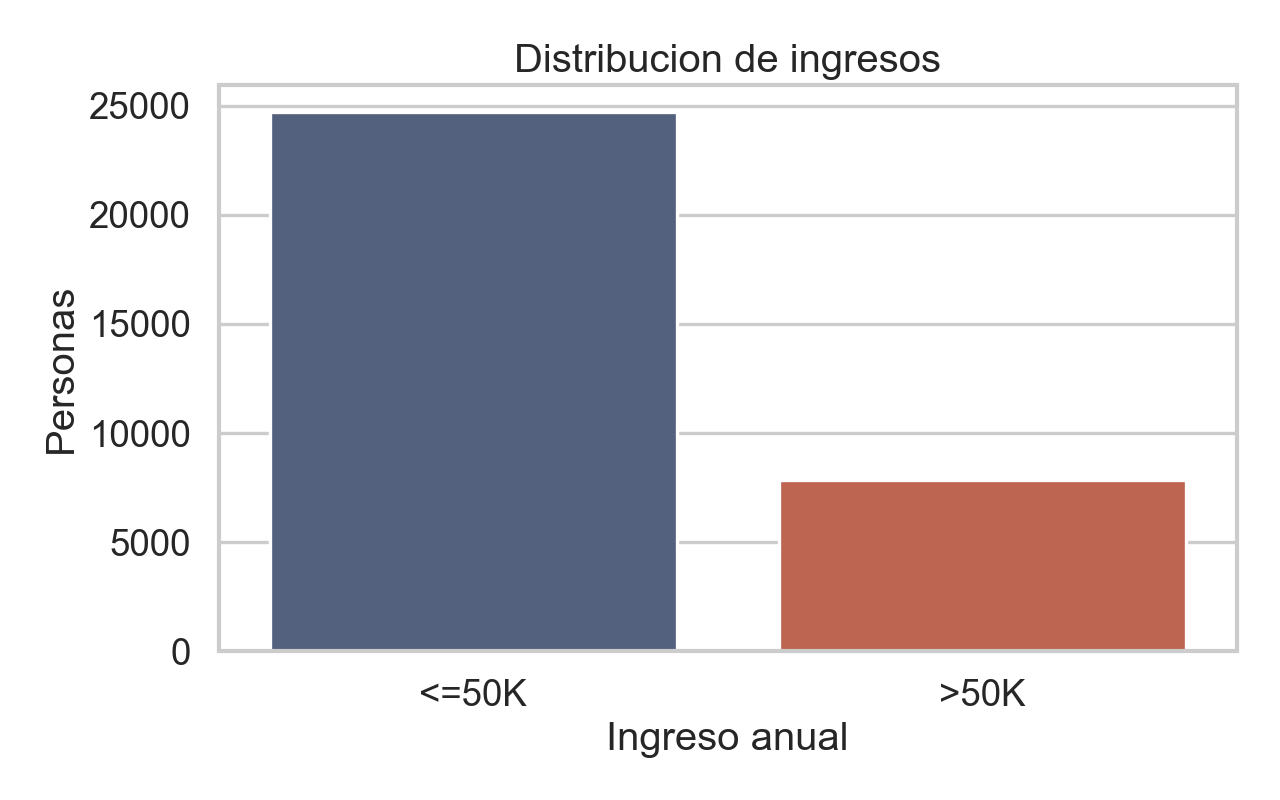

top_feature_importance.png


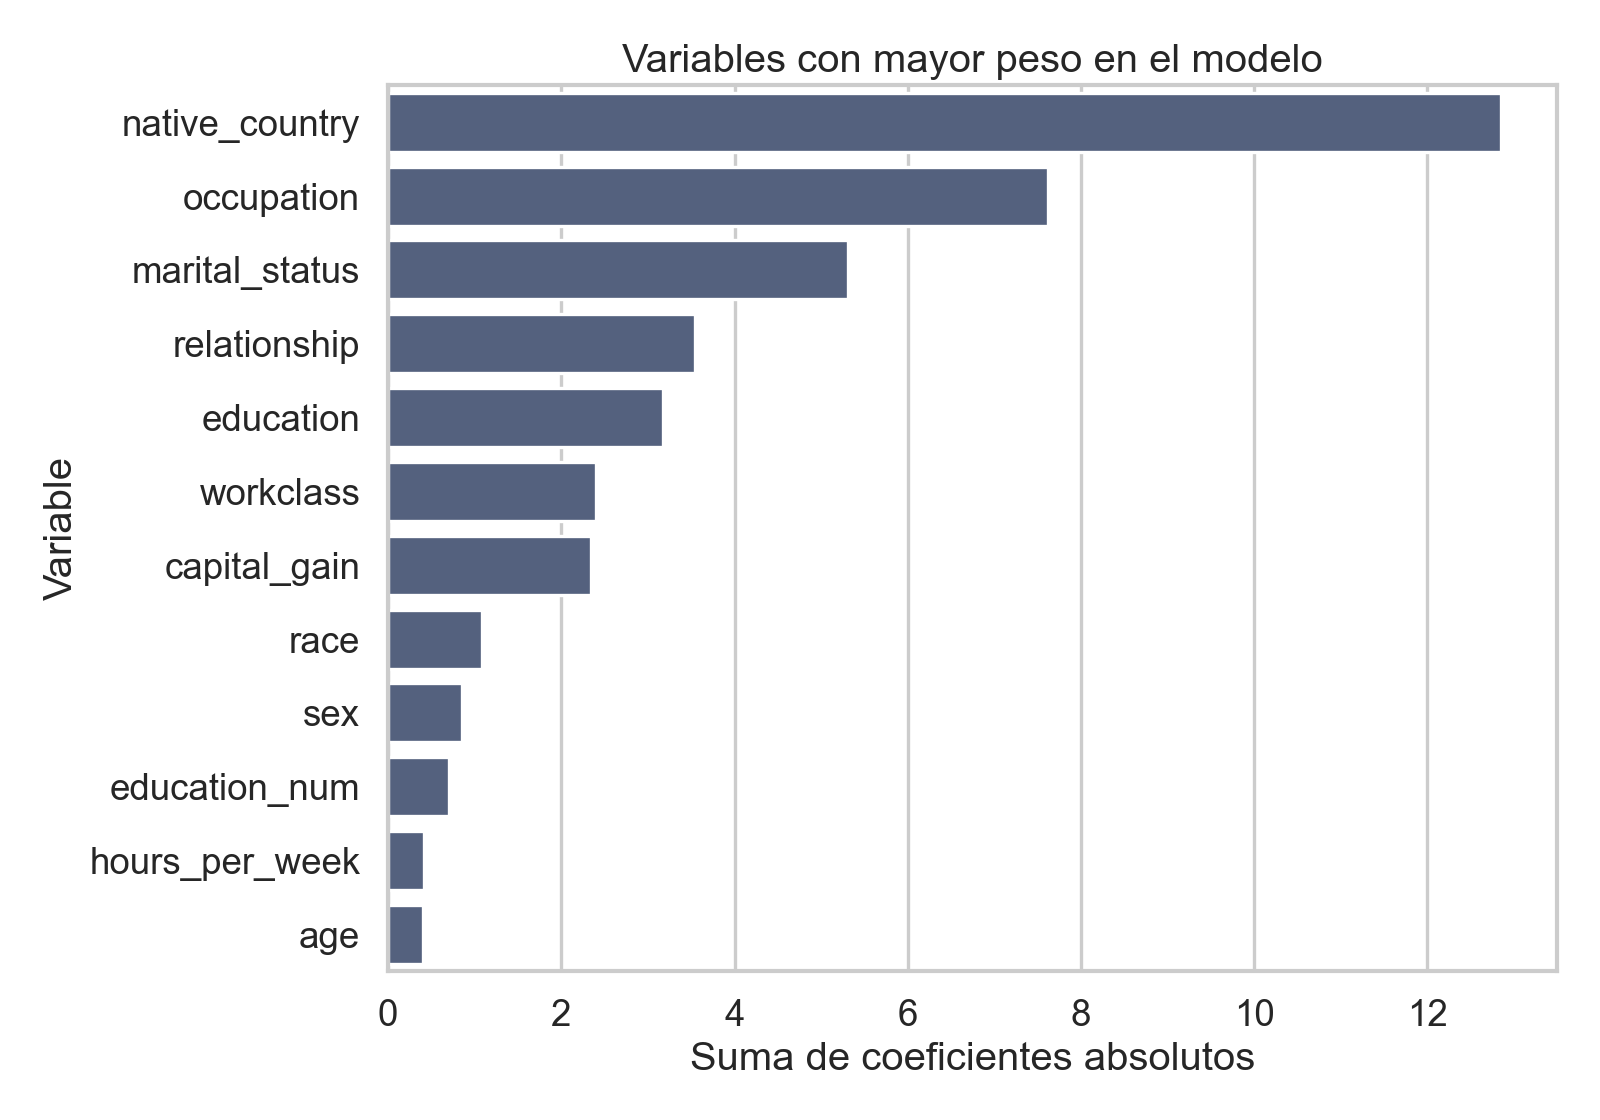

social_variable_importance.png


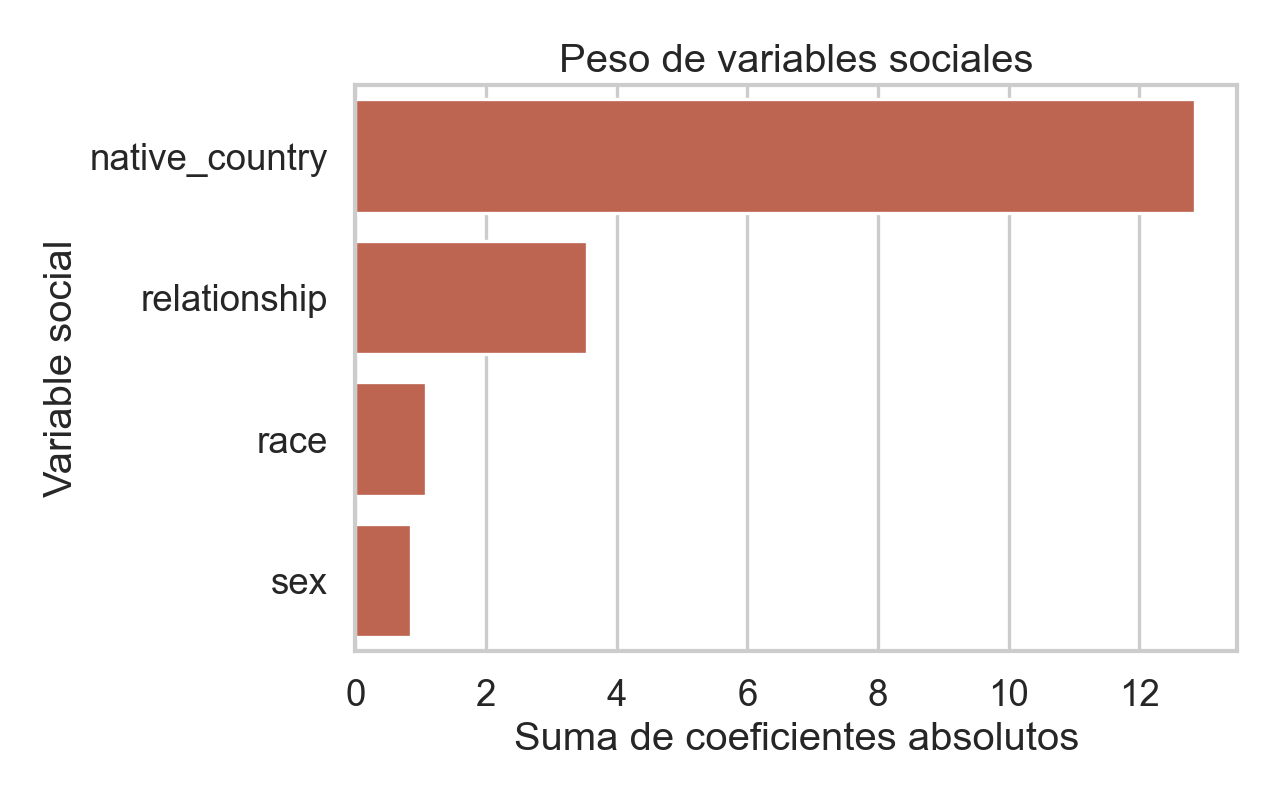

In [13]:
for figure in ["income_distribution.png", "top_feature_importance.png", "social_variable_importance.png"]:
    figure_path = PROJECT_ROOT / "reports" / "figures" / figure
    print(figure)
    display(Image(filename=str(figure_path)))

## 8. Artefactos finales

Al finalizar, el proyecto deja listos los archivos necesarios para entregar y reproducir el sistema.

In [14]:
artifacts = {
    "model": MODEL_PATH,
    "metrics": METRICS_PATH,
    "recommendations": RECOMMENDATIONS_PATH,
    "feature_importance": FEATURE_IMPORTANCE_PATH,
}

for name, path in artifacts.items():
    print(f"{name}: {path.relative_to(PROJECT_ROOT)} -> {path.exists()}")

model: models\adult_income_recommender.joblib -> True
metrics: models\adult_income_metrics.json -> True
recommendations: models\sample_recommendations.json -> True
feature_importance: models\feature_importance.json -> True
